In [8]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [9]:
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

# Normalize pixel values (0–255 → 0–1)
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

In [10]:
datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.1
)

datagen.fit(x_train)

In [11]:
model = models.Sequential()
model.add(layers.Conv2D(32, (3,3), padding='same', activation='relu', input_shape=(32,32,3)))
model.add(layers.BatchNormalization())
model.add(layers.Conv2D(32, (3,3), padding='same', activation='relu'))
model.add(layers.BatchNormalization())
model.add(layers.MaxPooling2D((2,2)))
model.add(layers.Dropout(0.25))

# ----- Block 2 -----
model.add(layers.Conv2D(64, (3,3), padding='same', activation='relu'))
model.add(layers.BatchNormalization())
model.add(layers.Conv2D(64, (3,3), padding='same', activation='relu'))
model.add(layers.BatchNormalization())
model.add(layers.MaxPooling2D((2,2)))
model.add(layers.Dropout(0.25))

# ----- Block 3 -----
model.add(layers.Conv2D(128, (3,3), padding='same', activation='relu'))
model.add(layers.BatchNormalization())
model.add(layers.MaxPooling2D((2,2)))
model.add(layers.Dropout(0.3))

# ----- Fully Connected -----
model.add(layers.Flatten())
model.add(layers.Dense(256, activation='relu'))
model.add(layers.BatchNormalization())
model.add(layers.Dropout(0.5))
model.add(layers.Dense(10, activation='softmax'))

In [12]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [13]:
history = model.fit(
    datagen.flow(x_train, y_train, batch_size=64),
    epochs=12,
    validation_data=(x_test, y_test)
)

Epoch 1/12
782/782 ━━━━━━━━━━━━━━━━━━━━ 385s 484ms/step - accuracy: 0.3345 - loss: 2.0694 - val_accuracy: 0.5306 - val_loss: 1.3242
Epoch 2/12
782/782 ━━━━━━━━━━━━━━━━━━━━ 378s 483ms/step - accuracy: 0.5413 - loss: 1.2767 - val_accuracy: 0.5242 - val_loss: 1.5045
Epoch 3/12
782/782 ━━━━━━━━━━━━━━━━━━━━ 376s 481ms/step - accuracy: 0.6111 - loss: 1.0983 - val_accuracy: 0.6894 - val_loss: 0.8952
Epoch 4/12
782/782 ━━━━━━━━━━━━━━━━━━━━ 372s 476ms/step - accuracy: 0.6482 - loss: 0.9919 - val_accuracy: 0.6574 - val_loss: 1.0356
Epoch 5/12
782/782 ━━━━━━━━━━━━━━━━━━━━ 377s 482ms/step - accuracy: 0.6787 - loss: 0.9129 - val_accuracy: 0.7451 - val_loss: 0.7543
Epoch 6/12
782/782 ━━━━━━━━━━━━━━━━━━━━ 372s 475ms/step - accuracy: 0.6963 - loss: 0.8688 - val_accuracy: 0.6456 - val_loss: 1.0511
Epoch 7/12
782/782 ━━━━━━━━━━━━━━━━━━━━ 371s 474ms/step - accuracy: 0.7119 - loss: 0.8299 - val_accuracy: 0.7600 - val_loss: 0.7020
Epoch 8/12
782/782 ━━━━━━━━━━━━━━━━━━━━ 370s 473ms/step - accuracy: 0.7226 -

In [14]:
test_loss, test_accuracy = model.evaluate(x_test, y_test)
print("Final Test Accuracy:", test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 17s 55ms/step - accuracy: 0.7490 - loss: 0.7499
Final Test Accuracy: 0.7495999932289124


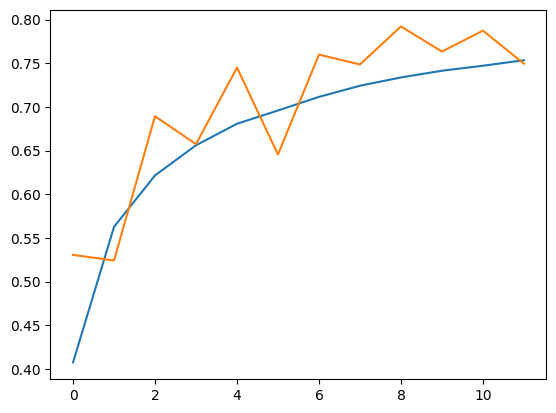

In [17]:
import matplotlib.pyplot as plt
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])